<a href="https://colab.research.google.com/github/angeruzzi/AutoVerifEmail_Langchain/blob/main/notebooks/08_score_and_credit_policy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 — Score e Política de Crédito

## Introdução

### 1. Contexto de Negócio

Nos notebooks anteriores, foram desenvolvidas e comparadas duas abordagens para estimar o risco de dificuldade de pagamento:

- uma Logistic Regression baseada em Binning, Weight of Evidence e Information Value;
- um LightGBM utilizado como modelo challenger.

Após a avaliação no holdout test, o LightGBM foi selecionado como **statistical champion**, apresentando melhor ROC-AUC, Gini, KS, PR-AUC, Brier Score e Log Loss. A superioridade também foi confirmada por meio de paired bootstrap.

Entretanto, a probabilidade de dificuldade de pagamento produzida pelo modelo não representa, por si só, uma decisão de crédito.

O modelo estima e ordena o risco. A Política de Crédito utiliza essa estimativa juntamente com regras, restrições, objetivos comerciais e informações adicionais para definir a decisão aplicável a cada cliente.

Neste notebook, as PDs produzidas pelo statistical champion serão transformadas em instrumentos mais próximos da utilização pela área de crédito:

- score;
- faixas de risco;
- ratings;
- cutoffs;
- indicadores de aprovação e risco.

### 2. Objetivos

Os principais objetivos deste notebook são:

1. transformar a PD estimada pelo LightGBM em uma escala de score;
2. demonstrar a relação inversa entre score e risco;
3. criar faixas de risco e ratings;
4. descrever a carteira por faixa de risco;
5. simular diferentes cutoffs de aprovação;
6. avaliar o trade-off entre approval rate e bad rate;
7. demonstrar como o modelo pode apoiar uma Política de Crédito;
8. documentar as limitações da simulação.

O propósito não é definir uma política real para a Home Credit, mas demonstrar como as previsões de um modelo de risco podem ser convertidas em informações utilizáveis em uma decisão de negócio.

### 3. Modelo de Risco e Política de Crédito

O modelo de risco responde principalmente à seguinte pergunta:

> Qual é o risco relativo ou a probabilidade estimada de este cliente apresentar dificuldade de pagamento?

A Política de Crédito responde a uma pergunta diferente:

> Considerando o risco estimado, as regras de elegibilidade, o retorno esperado e o apetite de risco, qual decisão deve ser tomada?

Uma política real poderia combinar o score com outros critérios, como:

- renda mínima;
- capacidade de pagamento;
- comprometimento de renda;
- valor e prazo solicitados;
- garantias;
- restrições cadastrais;
- limites de exposição;
- relacionamento com o cliente;
- prevenção à fraude;
- regras regulatórias;
- rentabilidade esperada.

Neste projeto, a simulação utilizará apenas as informações disponíveis na base e as PDs produzidas pelo modelo. Portanto, os resultados devem ser interpretados como uma demonstração analítica, e não como uma recomendação real de concessão.

### 4. Premissas e Limitações

A simulação será construída sob as seguintes premissas:

- `TARGET = 1` representa o evento de dificuldade de pagamento definido pela competição;
- a PD do LightGBM será utilizada como medida de risco;
- clientes com menor PD receberão scores maiores;
- clientes com scores maiores serão considerados de menor risco;
- os thresholds das faixas serão definidos na validation e aplicados ao holdout test;
- o holdout test permanecerá como amostra de avaliação final;
- os cutoffs serão simulados para fins comparativos, sem otimização de lucro.

A base não fornece todos os componentes necessários para uma política econômica completa. Em particular, não estão disponíveis estimativas validadas de:

- Loss Given Default — LGD;
- Exposure at Default — EAD;
- custo de capital;
- custo operacional;
- receita esperada;
- margem financeira;
- recuperação;
- fraude;
- elasticidade da demanda.

Consequentemente, não será calculada uma função real de rentabilidade ou Expected Loss completa.

Além disso, o statistical champion utiliza diretamente `CODE_GENDER`, atributo sensível que apresentou relevância na análise por SHAP. O modelo será mantido como benchmark para fins de portfólio, mas uma aplicação real exigiria uma versão governada sem a utilização direta desse atributo, investigação de possíveis proxies e avaliação adicional de fairness.

### 5. Etapas do Notebook

O notebook será organizado nas seguintes etapas:

1. configuração do ambiente;
2. carregamento das previsões do statistical champion;
3. transformação da PD em score;
4. validação da relação entre score e risco;
5. definição das faixas de risco;
6. análise da carteira por rating;
7. simulação de cutoffs;
8. análise do trade-off entre approval rate e bad rate;
9. persistência dos artefatos;
10. conclusão e recomendações.

Ao final, o projeto demonstrará a conexão entre modelagem de risco e Política de Crédito, preservando a distinção entre previsão estatística e decisão de negócio.

## Configuração do Ambiente

Nesta etapa, o repositório será disponibilizado no ambiente de execução, as dependências serão instaladas e os diretórios do projeto serão configurados.

No Google Colab, o código utiliza:

- o repositório clonado em `/content/home-credit-default-risk`;
- o Google Drive como cache persistente para dados e artefatos;
- a estrutura de diretórios definida em `utils.py`.

Caso existam alterações locais no repositório clonado, o `git pull` será ignorado para evitar a sobrescrita de arquivos ainda não versionados.

In [1]:
# Inicialização do projeto
import os
import sys
import subprocess
from pathlib import Path
import importlib

IN_COLAB = "google.colab" in sys.modules

REPOSITORY_URL = (
    "https://github.com/angeruzzi/"
    "home-credit-default-risk.git"
)

if IN_COLAB:
    PROJECT_ROOT = Path(
        "/content/home-credit-default-risk"
    )

    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(
            [
                "git",
                "clone",
                REPOSITORY_URL,
                str(PROJECT_ROOT),
            ],
            check=True,
        )

    else:
        git_status_result = subprocess.run(
            [
                "git",
                "-C",
                str(PROJECT_ROOT),
                "status",
                "--porcelain",
            ],
            check=True,
            capture_output=True,
            text=True,
        )

        if git_status_result.stdout.strip():
            print(
                "Alterações locais encontradas. "
                "O git pull não será executado."
            )

            print(
                git_status_result.stdout
            )

        else:
            subprocess.run(
                [
                    "git",
                    "-C",
                    str(PROJECT_ROOT),
                    "pull",
                    "--ff-only",
                    "origin",
                    "main",
                ],
                check=True,
            )

else:
    current_directory = Path.cwd().resolve()

    PROJECT_ROOT = (
        current_directory.parent
        if current_directory.name == "notebooks"
        else current_directory
    )

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /content/home-credit-default-risk


In [2]:
# Instalação das dependências
REQUIREMENTS_PATH = (
    PROJECT_ROOT / "requirements.txt"
)

if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: "
        f"{REQUIREMENTS_PATH}"
    )

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "-r",
        str(REQUIREMENTS_PATH),
    ],
    check=True,
)

print(
    "Dependências instaladas com sucesso."
)

Dependências instaladas com sucesso.


In [3]:
# Configuração dos diretórios do projeto
import utils

importlib.reload(utils)

from utils import setup_project

paths = setup_project(
    use_google_drive_cache=True,
)

print(paths)

Mounted at /content/drive
Ambiente Colab: True
Modo de armazenamento: Google Drive
Raiz do projeto: /content/home-credit-default-risk
Dados: /content/drive/MyDrive/home-credit-default-risk/data
Artefatos: /content/drive/MyDrive/home-credit-default-risk/artifacts
Relatórios: /content/home-credit-default-risk/reports
ProjectPaths(project_root=PosixPath('/content/home-credit-default-risk'), data_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data'), data_raw=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/raw'), data_interim=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/interim'), data_processed=PosixPath('/content/drive/MyDrive/home-credit-default-risk/data/processed'), artifacts_root=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts'), models=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/models'), preprocessing=PosixPath('/content/drive/MyDrive/home-credit-default-risk/artifacts/preprocessing'),

In [4]:
# Importação das bibliotecas
import json
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

from IPython.display import display
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    200,
)

pd.set_option(
    "display.max_rows",
    200,
)

pd.set_option(
    "display.float_format",
    "{:,.4f}".format,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

RANDOM_STATE = 42
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"
CHAMPION_PD_COLUMN = "challenger_pd"

print(
    "Bibliotecas importadas com sucesso."
)

Bibliotecas importadas com sucesso.


## Registro das Versões

As versões das principais bibliotecas serão registradas para facilitar a reprodução do notebook em outros ambientes.

Como esta etapa utiliza previsões já produzidas pelo statistical champion, não será realizado um novo treinamento do LightGBM.

In [5]:
# Registro das versões das bibliotecas
versions_table = pd.DataFrame(
    [
        {
            "component": "Python",
            "version": platform.python_version(),
        },
        {
            "component": "NumPy",
            "version": np.__version__,
        },
        {
            "component": "Pandas",
            "version": pd.__version__,
        },
        {
            "component": "SciPy",
            "version": scipy.__version__,
        },
        {
            "component": "Scikit-learn",
            "version": sklearn.__version__,
        },
        {
            "component": "Matplotlib",
            "version": (
                plt.matplotlib.__version__
            ),
        },
        {
            "component": "Seaborn",
            "version": sns.__version__,
        },
    ]
)

display(versions_table)

,component,version
0,Python,3.13.15
1,NumPy,2.1.3
2,Pandas,2.2.3
3,SciPy,1.16.3
4,Scikit-learn,1.6.1
5,Matplotlib,3.10.0
6,Seaborn,0.13.2


In [6]:
# Persistência do registro das versões
VERSIONS_PATH = (
    paths.metadata
    / "score_and_credit_policy_versions.csv"
)

versions_table.to_csv(
    VERSIONS_PATH,
    index=False,
)

print(
    f"Versões salvas em: {VERSIONS_PATH}"
)

Versões salvas em: /content/drive/MyDrive/home-credit-default-risk/artifacts/metadata/score_and_credit_policy_versions.csv


## Carregamento das Previsões do Champion

O LightGBM foi selecionado no Notebook 07 como statistical champion. Nesta etapa, suas previsões serão carregadas a partir do artefato persistido no Notebook 06.

Serão utilizadas principalmente duas amostras:

- **validation:** definição dos thresholds das faixas de risco e dos ratings;
- **holdout test:** avaliação final das faixas e simulação ilustrativa da Política de Crédito.

Os thresholds não serão definidos diretamente no holdout test, evitando utilizar a amostra final para tomar decisões metodológicas.

In [7]:
# Definição do caminho das previsões do champion
CHAMPION_PREDICTIONS_PATH = (
    paths.data_processed
    / "lightgbm_challenger_predictions.parquet"
)

if not CHAMPION_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        "Arquivo de previsões do champion "
        "não encontrado: "
        f"{CHAMPION_PREDICTIONS_PATH}"
    )

print(
    "Arquivo de previsões: "
    f"{CHAMPION_PREDICTIONS_PATH}"
)

Arquivo de previsões: /content/drive/MyDrive/home-credit-default-risk/data/processed/lightgbm_challenger_predictions.parquet


In [8]:
# Carregamento das previsões do champion
champion_predictions = pd.read_parquet(
    CHAMPION_PREDICTIONS_PATH
)

if (
    CHAMPION_PD_COLUMN
    not in champion_predictions.columns
):
    if (
        "predicted_pd"
        in champion_predictions.columns
    ):
        champion_predictions = (
            champion_predictions.rename(
                columns={
                    "predicted_pd": (
                        CHAMPION_PD_COLUMN
                    )
                }
            )
        )
    else:
        raise KeyError(
            "A coluna de PD não foi "
            "encontrada no artefato."
        )

print(
    "Dimensão das previsões: "
    f"{champion_predictions.shape}"
)

display(
    champion_predictions.head()
)

Dimensão das previsões: (307511, 4)


,SK_ID_CURR,TARGET,sample,challenger_pd
0,285133,0,train,0.0275
1,191894,0,train,0.0373
2,369428,0,train,0.0382
3,138717,0,train,0.0230
4,202381,0,train,0.0325


In [9]:
# Construção do resumo das amostras
champion_sample_summary = (
    champion_predictions
    .groupby(
        "sample",
        observed=True,
    )
    .agg(
        clients=(
            ID_COLUMN,
            "size",
        ),
        events=(
            TARGET_COLUMN,
            "sum",
        ),
        event_rate=(
            TARGET_COLUMN,
            "mean",
        ),
        minimum_pd=(
            CHAMPION_PD_COLUMN,
            "min",
        ),
        mean_pd=(
            CHAMPION_PD_COLUMN,
            "mean",
        ),
        maximum_pd=(
            CHAMPION_PD_COLUMN,
            "max",
        ),
    )
    .reset_index()
)

display(champion_sample_summary)

,sample,clients,events,event_rate,minimum_pd,mean_pd,maximum_pd
0,holdout_test,46127,3724,0.0807,0.0011,0.0804,0.8780
1,train,215257,17377,0.0807,0.0009,0.0808,0.9300
2,validation,46127,3724,0.0807,0.0011,0.0807,0.8420


## Transformação da PD em Score

### 6. Definição da Escala

A Probability of Default — PD — é tecnicamente adequada para representar risco, mas uma escala de score costuma ser mais conveniente para comunicação, definição de faixas e aplicação de cutoffs.

A transformação será construída de forma que:

- PD maior represente risco maior;
- score maior represente risco menor;
- a ordenação dos clientes seja preservada;
- o aumento do score possua interpretação consistente em termos de odds.

Serão utilizados três parâmetros:

- **Base Score:** score associado a uma determinada razão entre bons e maus;
- **Base Odds:** razão entre a probabilidade de não evento e a probabilidade de evento no Base Score;
- **Points to Double the Odds — PDO:** quantidade de pontos necessária para duplicar as odds de bom para mau.

Neste projeto, serão adotados parâmetros ilustrativos:

- Base Score: 600 pontos;
- Base Odds: 20 bons para 1 mau;
- PDO: 50 pontos.

As odds de bom para mau são definidas por:

$$
\text{Odds}_{good:bad}
=
\frac{1-PD}{PD}
$$

O fator da escala é dado por:

$$
\text{Factor}
=
\frac{PDO}{\ln(2)}
$$

O score será calculado por:

$$
\text{Score}
=
\text{Base Score}
+
\text{Factor}
\cdot
\ln
\left(
\frac{\text{Odds}_{good:bad}}
{\text{Base Odds}}
\right)
$$

Com essa parametrização, um cliente com odds de 20 bons para 1 mau recebe score 600. Se as odds dobrarem para 40:1, o score aumenta para 650. Se forem reduzidas pela metade para 10:1, o score diminui para 550.

Esses parâmetros não foram estimados a partir dos dados e não representam uma escala oficial da Home Credit. Eles foram definidos para demonstrar a transformação de uma PD em uma escala de score interpretável.

In [10]:
# Definição dos parâmetros da escala de score
BASE_SCORE = 600
BASE_ODDS = 20
PDO = 50

SCORE_FACTOR = (
    PDO / np.log(2)
)

SCORE_OFFSET = (
    BASE_SCORE
    - SCORE_FACTOR * np.log(BASE_ODDS)
)

score_parameters = pd.DataFrame(
    {
        "parameter": [
            "Base Score",
            "Base Odds",
            "PDO",
            "Factor",
            "Offset",
        ],
        "value": [
            BASE_SCORE,
            BASE_ODDS,
            PDO,
            SCORE_FACTOR,
            SCORE_OFFSET,
        ],
    }
)

display(score_parameters)

,parameter,value
0,Base Score,600.0000
1,Base Odds,20.0000
2,PDO,50.0000
3,Factor,72.1348
4,Offset,383.9036


In [11]:
# Função de transformação da PD em score
def probability_to_score(
    probability,
    base_score=BASE_SCORE,
    base_odds=BASE_ODDS,
    pdo=PDO,
    epsilon=1e-6,
):
    probability = np.asarray(
        probability,
        dtype=float,
    )

    adjusted_probability = np.clip(
        probability,
        epsilon,
        1 - epsilon,
    )

    good_bad_odds = (
        (1 - adjusted_probability)
        / adjusted_probability
    )

    factor = pdo / np.log(2)

    score = (
        base_score
        + factor
        * np.log(
            good_bad_odds / base_odds
        )
    )

    return score

In [12]:
# Aplicação da transformação nas previsões
score_data = champion_predictions.copy()

score_data["credit_score"] = (
    probability_to_score(
        score_data[
            CHAMPION_PD_COLUMN
        ]
    )
)

score_data["credit_score_rounded"] = (
    score_data["credit_score"]
    .round()
    .astype(int)
)

display(
    score_data[
        [
            ID_COLUMN,
            TARGET_COLUMN,
            "sample",
            CHAMPION_PD_COLUMN,
            "credit_score",
            "credit_score_rounded",
        ]
    ].head()
)

,SK_ID_CURR,TARGET,sample,challenger_pd,credit_score,credit_score_rounded
0,285133,0,train,0.0275,641.1711,641
1,191894,0,train,0.0373,618.4199,618
2,369428,0,train,0.0382,616.6286,617
3,138717,0,train,0.0230,654.4153,654
4,202381,0,train,0.0325,628.7588,629


In [13]:
# Validação da escala de score
score_sample_summary = (
    score_data
    .groupby(
        "sample",
        observed=True,
    )
    .agg(
        clients=(
            ID_COLUMN,
            "size",
        ),
        minimum_pd=(
            CHAMPION_PD_COLUMN,
            "min",
        ),
        maximum_pd=(
            CHAMPION_PD_COLUMN,
            "max",
        ),
        minimum_score=(
            "credit_score",
            "min",
        ),
        mean_score=(
            "credit_score",
            "mean",
        ),
        median_score=(
            "credit_score",
            "median",
        ),
        maximum_score=(
            "credit_score",
            "max",
        ),
    )
    .reset_index()
)

display(score_sample_summary)

,sample,clients,minimum_pd,maximum_pd,minimum_score,mean_score,median_score,maximum_score
0,holdout_test,46127,0.0011,0.8780,241.5568,597.7422,603.4399,876.0158
1,train,215257,0.0009,0.9300,197.3362,597.2374,602.8139,887.0548
2,validation,46127,0.0011,0.8420,263.2133,596.9238,602.3671,874.9118


### 7. Validação da Relação entre Score e Risco

A transformação da PD em score é monotônica e inversa:

- quando a PD aumenta, o score diminui;
- quando a PD diminui, o score aumenta.

Por se tratar de uma transformação monotônica, ela não altera a ordenação dos clientes. Consequentemente, métricas de ranking, como ROC-AUC, Gini e KS, permanecem as mesmas quando calculadas a partir do score, desde que a direção seja tratada corretamente.

Como scores maiores representam menor risco, uma avaliação por score deve utilizar `-score` quando a métrica espera que valores maiores representem maior probabilidade de evento.

A ausência de limites artificiais produziu alguns valores fora da faixa frequentemente observada de 300 a 850. Isso é esperado e não constitui erro. Os valores resultam diretamente das PDs e dos parâmetros escolhidos para a escala.

In [14]:
# Construção de exemplos da transformação PD em score
score_reference_probabilities = np.array(
    [
        0.01,
        1 / 41,
        1 / 21,
        1 / 11,
        0.10,
        0.20,
        0.50,
    ]
)

score_reference_table = pd.DataFrame(
    {
        "pd": score_reference_probabilities,
    }
)

score_reference_table[
    "good_bad_odds"
] = (
    1 - score_reference_table["pd"]
) / score_reference_table["pd"]

score_reference_table[
    "credit_score"
] = probability_to_score(
    score_reference_table["pd"]
)

score_reference_table[
    "credit_score_rounded"
] = (
    score_reference_table[
        "credit_score"
    ]
    .round()
    .astype(int)
)

display(score_reference_table)

,pd,good_bad_odds,credit_score,credit_score_rounded
0,0.0100,99.0000,715.3714,715
1,0.0244,40.0000,650.0000,650
2,0.0476,20.0000,600.0000,600
3,0.0909,10.0000,550.0000,550
4,0.1000,9.0000,542.3998,542
5,0.2000,4.0000,483.9036,484
6,0.5000,1.0000,383.9036,384


In [15]:
# Validação da monotonicidade da transformação
score_relationship_records = []

for sample_name, sample_data in score_data.groupby(
    "sample",
    observed=True,
):
    spearman_result = scipy.stats.spearmanr(
        sample_data[CHAMPION_PD_COLUMN],
        sample_data["credit_score"],
    )

    score_relationship_records.append(
        {
            "sample": sample_name,
            "spearman_pd_score": (
                spearman_result.statistic
            ),
            "p_value": (
                spearman_result.pvalue
            ),
            "unique_pd": sample_data[
                CHAMPION_PD_COLUMN
            ].nunique(),
            "unique_continuous_score": (
                sample_data[
                    "credit_score"
                ].nunique()
            ),
            "unique_rounded_score": (
                sample_data[
                    "credit_score_rounded"
                ].nunique()
            ),
        }
    )

score_relationship_summary = pd.DataFrame(
    score_relationship_records
)

display(score_relationship_summary)

,sample,spearman_pd_score,p_value,unique_pd,unique_continuous_score,unique_rounded_score
0,holdout_test,-1.0000,0.0000,46127,46127,548
1,train,-1.0000,0.0000,215257,215257,597
2,validation,-1.0000,0.0000,46127,46127,536


In [16]:
# Verificação dos parâmetros centrais da escala
base_pd = 1 / (1 + BASE_ODDS)

score_at_base_odds = probability_to_score(
    [base_pd]
)[0]

score_at_double_odds = probability_to_score(
    [1 / (1 + 2 * BASE_ODDS)]
)[0]

score_at_half_odds = probability_to_score(
    [1 / (1 + BASE_ODDS / 2)]
)[0]

score_scale_validation = pd.DataFrame(
    {
        "reference": [
            "Metade das Base Odds",
            "Base Odds",
            "Dobro das Base Odds",
        ],
        "good_bad_odds": [
            BASE_ODDS / 2,
            BASE_ODDS,
            BASE_ODDS * 2,
        ],
        "expected_score": [
            BASE_SCORE - PDO,
            BASE_SCORE,
            BASE_SCORE + PDO,
        ],
        "calculated_score": [
            score_at_half_odds,
            score_at_base_odds,
            score_at_double_odds,
        ],
    }
)

score_scale_validation[
    "difference"
] = (
    score_scale_validation[
        "calculated_score"
    ]
    - score_scale_validation[
        "expected_score"
    ]
)

display(score_scale_validation)

,reference,good_bad_odds,expected_score,calculated_score,difference
0,Metade das Base Odds,10.0000,550,550.0000,0.0000
1,Base Odds,20.0000,600,600.0000,0.0000
2,Dobro das Base Odds,40.0000,650,650.0000,0.0000


### 8. Definição das Faixas de Risco

Os scores serão agrupados em cinco ratings:

- **A:** menor risco;
- **B:** risco baixo;
- **C:** risco intermediário;
- **D:** risco elevado;
- **E:** maior risco.

Os thresholds serão definidos pelos quintis do score na amostra de validation. Cada faixa conterá inicialmente aproximadamente 20% dos clientes dessa amostra.

Depois de definidos, os mesmos thresholds serão aplicados ao holdout test. Dessa forma, a distribuição do holdout poderá variar livremente, simulando a aplicação de uma régua previamente estabelecida em uma nova população.

Como scores maiores representam menor risco, os 20% maiores scores receberão rating A e os 20% menores receberão rating E.

Esses ratings são relativos à população utilizada no projeto. Eles não representam ratings externos, classificações regulatórias ou níveis absolutos de risco adotados por uma instituição financeira.

In [17]:
# Separação da amostra de validation
validation_score_data = (
    score_data.loc[
        score_data["sample"].eq(
            "validation"
        )
    ]
    .copy()
)

if validation_score_data.empty:
    raise ValueError(
        "A amostra de validation está vazia."
    )

print(
    "Clientes na validation: "
    f"{len(validation_score_data):,}"
)

Clientes na validation: 46,127


In [18]:
# Definição dos thresholds pelas distribuições da validation
rating_quantiles = (
    validation_score_data[
        "credit_score"
    ]
    .quantile(
        [
            0.20,
            0.40,
            0.60,
            0.80,
        ]
    )
)

SCORE_Q20 = rating_quantiles.loc[0.20]
SCORE_Q40 = rating_quantiles.loc[0.40]
SCORE_Q60 = rating_quantiles.loc[0.60]
SCORE_Q80 = rating_quantiles.loc[0.80]

rating_thresholds = pd.DataFrame(
    {
        "rating": [
            "A",
            "B",
            "C",
            "D",
            "E",
        ],
        "risk_level": [
            "Menor risco",
            "Risco baixo",
            "Risco intermediário",
            "Risco elevado",
            "Maior risco",
        ],
        "minimum_score": [
            SCORE_Q80,
            SCORE_Q60,
            SCORE_Q40,
            SCORE_Q20,
            -np.inf,
        ],
        "maximum_score": [
            np.inf,
            SCORE_Q80,
            SCORE_Q60,
            SCORE_Q40,
            SCORE_Q20,
        ],
    }
)

display(rating_thresholds)

,rating,risk_level,minimum_score,maximum_score
0,A,Menor risco,668.0324,inf
1,B,Risco baixo,622.8721,668.0324
2,C,Risco intermediário,580.2656,622.8721
3,D,Risco elevado,527.3916,580.2656
4,E,Maior risco,-inf,527.3916


In [19]:
# Função de atribuição dos ratings
def assign_risk_rating(
    score,
    score_q20=SCORE_Q20,
    score_q40=SCORE_Q40,
    score_q60=SCORE_Q60,
    score_q80=SCORE_Q80,
):
    rating = pd.cut(
        score,
        bins=[
            -np.inf,
            score_q20,
            score_q40,
            score_q60,
            score_q80,
            np.inf,
        ],
        labels=[
            "E",
            "D",
            "C",
            "B",
            "A",
        ],
        include_lowest=True,
        right=True,
    )

    return rating

In [20]:
# Aplicação dos ratings com thresholds da validation
score_data["risk_rating"] = (
    assign_risk_rating(
        score_data["credit_score"]
    )
)

score_data["risk_rating"] = pd.Categorical(
    score_data["risk_rating"],
    categories=[
        "A",
        "B",
        "C",
        "D",
        "E",
    ],
    ordered=True,
)

if score_data["risk_rating"].isna().any():
    raise ValueError(
        "Existem clientes sem rating."
    )

print(
    "Ratings atribuídos com sucesso."
)

Ratings atribuídos com sucesso.


In [21]:
# Construção da distribuição dos ratings
rating_distribution = (
    score_data.loc[
        score_data["sample"].isin(
            [
                "validation",
                "holdout_test",
            ]
        )
    ]
    .groupby(
        [
            "sample",
            "risk_rating",
        ],
        observed=False,
    )
    .size()
    .rename("clients")
    .reset_index()
)

rating_distribution[
    "portfolio_share"
] = (
    rating_distribution["clients"]
    / rating_distribution.groupby(
        "sample"
    )["clients"].transform("sum")
)

display(rating_distribution)

,sample,risk_rating,clients,portfolio_share
0,holdout_test,A,9436,0.2046
1,holdout_test,B,9296,0.2015
2,holdout_test,C,9236,0.2002
3,holdout_test,D,9084,0.1969
4,holdout_test,E,9075,0.1967
5,validation,A,9226,0.2000
6,validation,B,9225,0.2000
7,validation,C,9225,0.2000
8,validation,D,9225,0.2000
9,validation,E,9226,0.2000


## Perfil de Risco por Rating

### 9. Caracterização das Faixas

Após a definição dos thresholds na validation, as faixas serão caracterizadas pela quantidade de clientes, participação na carteira, PD média e bad rate observado.

Uma segmentação de risco adequada deve apresentar ordenação consistente:

- o score médio deve diminuir de A para E;
- a PD média deve aumentar de A para E;
- o bad rate observado também deve aumentar de A para E.

A proximidade entre a PD média e o bad rate permite avaliar a calibração dentro de cada rating. A participação nos eventos mostra em quais faixas estão concentrados os clientes com dificuldade de pagamento.

In [22]:
# Função de construção do perfil por rating
def build_rating_profile(
    data,
    sample_name,
):
    sample_data = data.loc[
        data["sample"].eq(
            sample_name
        )
    ].copy()

    rating_profile = (
        sample_data
        .groupby(
            "risk_rating",
            observed=False,
        )
        .agg(
            clients=(
                ID_COLUMN,
                "size",
            ),
            events=(
                TARGET_COLUMN,
                "sum",
            ),
            minimum_score=(
                "credit_score",
                "min",
            ),
            maximum_score=(
                "credit_score",
                "max",
            ),
            mean_score=(
                "credit_score",
                "mean",
            ),
            minimum_pd=(
                CHAMPION_PD_COLUMN,
                "min",
            ),
            maximum_pd=(
                CHAMPION_PD_COLUMN,
                "max",
            ),
            mean_predicted_pd=(
                CHAMPION_PD_COLUMN,
                "mean",
            ),
            observed_bad_rate=(
                TARGET_COLUMN,
                "mean",
            ),
        )
        .reset_index()
    )

    rating_profile.insert(
        0,
        "sample",
        sample_name,
    )

    rating_profile[
        "portfolio_share"
    ] = (
        rating_profile["clients"]
        / rating_profile["clients"].sum()
    )

    rating_profile[
        "event_share"
    ] = (
        rating_profile["events"]
        / rating_profile["events"].sum()
    )

    rating_profile[
        "calibration_difference"
    ] = (
        rating_profile["mean_predicted_pd"]
        - rating_profile["observed_bad_rate"]
    )

    return rating_profile

In [23]:
# Construção dos perfis de risco
validation_rating_profile = (
    build_rating_profile(
        data=score_data,
        sample_name="validation",
    )
)

holdout_rating_profile = (
    build_rating_profile(
        data=score_data,
        sample_name="holdout_test",
    )
)

rating_profile_comparison = pd.concat(
    [
        validation_rating_profile,
        holdout_rating_profile,
    ],
    ignore_index=True,
)

display(validation_rating_profile)
display(holdout_rating_profile)

,sample,risk_rating,clients,events,minimum_score,maximum_score,mean_score,minimum_pd,maximum_pd,mean_predicted_pd,observed_bad_rate,portfolio_share,event_share,calibration_difference
0,validation,A,9226,109,668.0330,874.9118,705.9510,0.0011,0.0191,0.0122,0.0118,0.2000,0.0293,0.0004
1,validation,B,9225,235,622.8734,668.0304,644.8495,0.0191,0.0351,0.0265,0.0255,0.2000,0.0631,0.0011
2,validation,C,9225,416,580.2829,622.8703,602.0577,0.0351,0.0617,0.0469,0.0451,0.2000,0.1117,0.0018
3,validation,D,9225,826,527.4006,580.2540,555.5152,0.0617,0.1203,0.0862,0.0895,0.2000,0.2218,-0.0033
4,validation,E,9226,2138,263.2133,527.3894,476.2468,0.1203,0.8420,0.2318,0.2317,0.2000,0.5741,0.0000


,sample,risk_rating,clients,events,minimum_score,maximum_score,mean_score,minimum_pd,maximum_pd,mean_predicted_pd,observed_bad_rate,portfolio_share,event_share,calibration_difference
0,holdout_test,A,9436,117,668.0410,876.0158,706.3984,0.0011,0.0191,0.0122,0.0124,0.2046,0.0314,-0.0002
1,holdout_test,B,9296,234,622.8789,668.0210,644.3564,0.0191,0.0351,0.0267,0.0252,0.2015,0.0628,0.0015
2,holdout_test,C,9236,438,580.2697,622.8705,601.8934,0.0351,0.0617,0.0470,0.0474,0.2002,0.1176,-0.0004
3,holdout_test,D,9084,738,527.4055,580.2640,555.4746,0.0617,0.1203,0.0863,0.0812,0.1969,0.1982,0.0050
4,holdout_test,E,9075,2197,241.5568,527.3784,475.0991,0.1204,0.8780,0.2346,0.2421,0.1967,0.5900,-0.0075


### Interpretação do Perfil por Rating

As faixas apresentaram ordenação monotônica no holdout test. À medida que o rating se desloca de A para E, o score médio diminui e tanto a PD média quanto o bad rate observado aumentam.

Os bad rates observados foram:

- rating A: aproximadamente 1,24%;
- rating B: aproximadamente 2,52%;
- rating C: aproximadamente 4,74%;
- rating D: aproximadamente 8,12%;
- rating E: aproximadamente 24,21%.

O rating E representa aproximadamente 19,67% da carteira, mas concentra 59,00% dos eventos. Em contraste, o rating A representa 20,46% da carteira e concentra apenas 3,14% dos eventos.

A PD média permaneceu próxima do bad rate em todas as faixas. O maior desvio absoluto ocorreu no rating E, no qual a PD média de 23,46% subestimou em aproximadamente 0,75 ponto percentual o bad rate observado de 24,21%.

Os resultados demonstram que os thresholds definidos na validation foram capazes de produzir faixas ordenadas, discriminantes e razoavelmente calibradas no holdout test.

### 10. Visualização do Perfil por Rating

A primeira visualização compara a PD média com o bad rate observado em cada rating. A segunda compara a participação de cada faixa na carteira com sua participação no total de eventos.

Uma segmentação eficiente deve apresentar:

- risco crescente de A para E;
- proximidade entre PD média e bad rate;
- concentração dos eventos nas faixas de maior risco.

In [24]:
# Preparação dos dados para visualização por rating
holdout_rating_plot_data = (
    holdout_rating_profile
    .sort_values("risk_rating")
    .reset_index(drop=True)
)

rating_labels = (
    holdout_rating_plot_data[
        "risk_rating"
    ]
    .astype(str)
    .tolist()
)

rating_positions = np.arange(
    len(rating_labels)
)

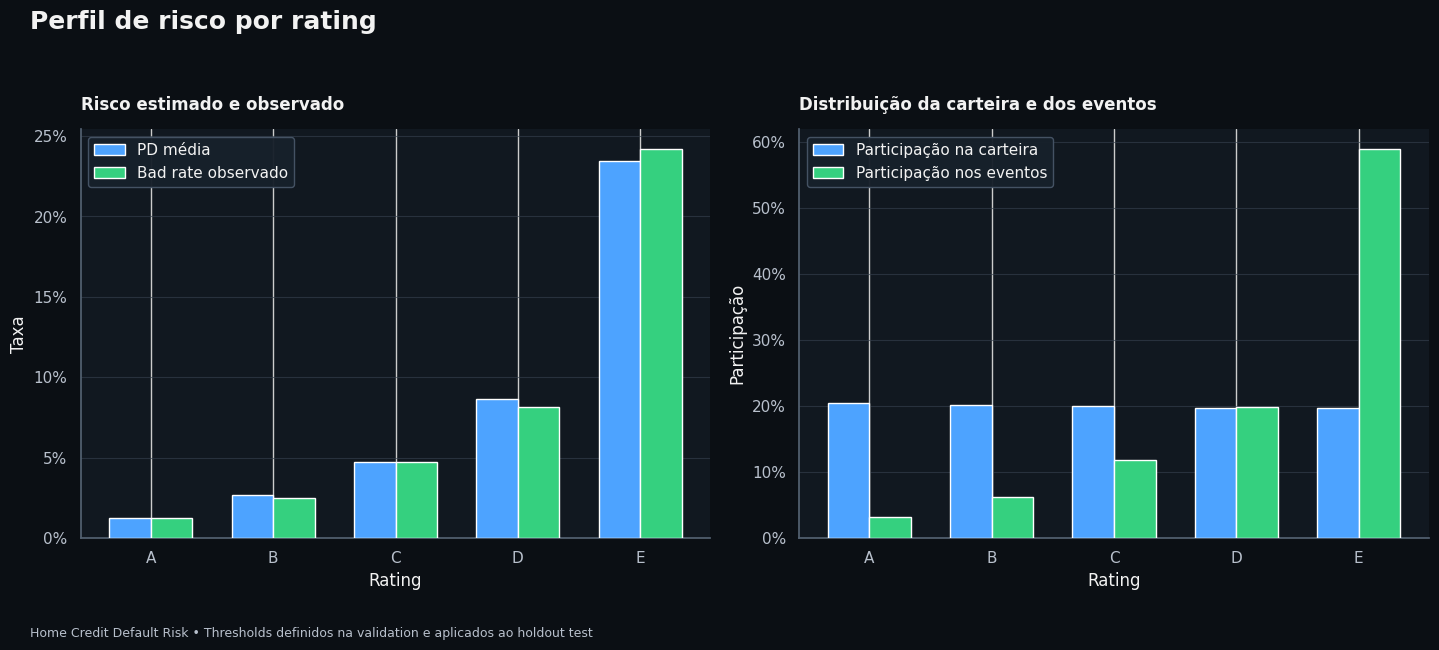

Figura salva em: /content/home-credit-default-risk/reports/figures/score_policy_rating_profile.png


In [25]:
# Visualização do perfil de risco por rating
background_color = "#0B0F14"
plot_background_color = "#111820"

blue_color = "#4DA3FF"
green_color = "#35D07F"
secondary_text_color = "#B8C0CC"
primary_text_color = "#F2F2F2"
grid_color = "#35404D"

bar_width = 0.34

with plt.rc_context(
    {
        "font.family": "sans-serif",
        "text.color": primary_text_color,
        "axes.labelcolor": primary_text_color,
        "xtick.color": secondary_text_color,
        "ytick.color": secondary_text_color,
        "axes.titleweight": "bold",
    }
):
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(15, 6.5),
        facecolor=background_color,
    )

    for axis in axes:
        axis.set_facecolor(
            plot_background_color
        )

        axis.spines["top"].set_visible(
            False
        )

        axis.spines["right"].set_visible(
            False
        )

        axis.spines["left"].set_color(
            "#536171"
        )

        axis.spines["bottom"].set_color(
            "#536171"
        )

        axis.grid(
            axis="y",
            color=grid_color,
            linewidth=0.8,
            alpha=0.65,
        )

    # Comparação entre PD e bad rate
    axes[0].bar(
        rating_positions - bar_width / 2,
        holdout_rating_plot_data[
            "mean_predicted_pd"
        ],
        width=bar_width,
        color=blue_color,
        label="PD média",
        zorder=3,
    )

    axes[0].bar(
        rating_positions + bar_width / 2,
        holdout_rating_plot_data[
            "observed_bad_rate"
        ],
        width=bar_width,
        color=green_color,
        label="Bad rate observado",
        zorder=3,
    )

    axes[0].set_title(
        "Risco estimado e observado",
        loc="left",
        color=primary_text_color,
        pad=14,
    )

    axes[0].set_xlabel("Rating")
    axes[0].set_ylabel("Taxa")
    axes[0].set_xticks(
        rating_positions,
        rating_labels,
    )

    axes[0].yaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=0,
        )
    )

    # Participação na carteira e nos eventos
    axes[1].bar(
        rating_positions - bar_width / 2,
        holdout_rating_plot_data[
            "portfolio_share"
        ],
        width=bar_width,
        color=blue_color,
        label="Participação na carteira",
        zorder=3,
    )

    axes[1].bar(
        rating_positions + bar_width / 2,
        holdout_rating_plot_data[
            "event_share"
        ],
        width=bar_width,
        color=green_color,
        label="Participação nos eventos",
        zorder=3,
    )

    axes[1].set_title(
        "Distribuição da carteira e dos eventos",
        loc="left",
        color=primary_text_color,
        pad=14,
    )

    axes[1].set_xlabel("Rating")
    axes[1].set_ylabel("Participação")
    axes[1].set_xticks(
        rating_positions,
        rating_labels,
    )

    axes[1].yaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=0,
        )
    )

    for axis in axes:
        legend = axis.legend(
            frameon=True,
            facecolor="#17212B",
            edgecolor="#465466",
            framealpha=0.97,
        )

        for legend_text in (
            legend.get_texts()
        ):
            legend_text.set_color(
                primary_text_color
            )

    figure.suptitle(
        "Perfil de risco por rating",
        fontsize=18,
        fontweight="bold",
        color=primary_text_color,
        x=0.055,
        ha="left",
    )

    footer_text = (
        "Home Credit Default Risk • "
        "Thresholds definidos na validation "
        "e aplicados ao holdout test"
    )

    figure.text(
        0.055,
        0.015,
        footer_text,
        fontsize=9,
        color=secondary_text_color,
    )

    figure.tight_layout(
        rect=[0.03, 0.06, 1, 0.94]
    )

    RATING_PROFILE_FIGURE_PATH = (
        paths.figures
        / "score_policy_rating_profile.png"
    )

    figure.savefig(
        RATING_PROFILE_FIGURE_PATH,
        dpi=220,
        bbox_inches="tight",
        facecolor=background_color,
    )

    plt.show()

print(
    "Figura salva em: "
    f"{RATING_PROFILE_FIGURE_PATH}"
)

## Simulação da Política de Crédito

### 11. Definição dos Cutoffs

A simulação considerará uma política simplificada:

> Aprovar clientes com score maior ou igual ao cutoff e rejeitar clientes com score inferior ao cutoff.

Os cutoffs serão definidos na amostra de validation para produzir approval rates teóricos entre 20% e 90%. Em seguida, esses mesmos cutoffs serão aplicados ao holdout test.

Como a distribuição do holdout pode ser diferente, o approval rate efetivamente observado poderá apresentar pequenas diferenças em relação ao percentual definido na validation.

Para cada cenário serão calculados:

- **approval rate:** proporção de clientes aprovados;
- **approved bad rate:** taxa observada de eventos entre os aprovados;
- **rejected bad rate:** taxa observada de eventos entre os rejeitados;
- **rejected event capture:** proporção de todos os eventos concentrada entre os rejeitados;
- **approved good capture:** proporção de todos os clientes sem evento que foi aprovada;
- **PD média dos aprovados:** risco médio estimado da carteira aprovada.

Essas métricas representam uma avaliação retrospectiva, pois utilizam o target já observado. Em uma operação real, o resultado dos clientes rejeitados normalmente não seria observado sem estratégias específicas, produzindo o problema conhecido como reject inference.

In [26]:
# Definição dos approval rates simulados
target_approval_rates = np.arange(
    0.20,
    1.00,
    0.10,
)

validation_scores = (
    validation_score_data[
        "credit_score"
    ]
    .to_numpy()
)

policy_cutoff_records = []

for target_approval_rate in (
    target_approval_rates
):
    score_cutoff = np.quantile(
        validation_scores,
        1 - target_approval_rate,
    )

    maximum_approved_pd = (
        1
        / (
            1
            + BASE_ODDS
            * np.exp(
                (
                    score_cutoff
                    - BASE_SCORE
                )
                / SCORE_FACTOR
            )
        )
    )

    policy_cutoff_records.append(
        {
            "target_approval_rate": (
                target_approval_rate
            ),
            "score_cutoff": score_cutoff,
            "maximum_approved_pd": (
                maximum_approved_pd
            ),
        }
    )

policy_cutoffs = pd.DataFrame(
    policy_cutoff_records
)

display(policy_cutoffs)

,target_approval_rate,score_cutoff,maximum_approved_pd
0,0.2000,668.0324,0.0191
1,0.3000,644.5170,0.0263
2,0.4000,622.8721,0.0351
3,0.5000,602.3671,0.0462
4,0.6000,580.2656,0.0617
5,0.7000,556.3876,0.0839
6,0.8000,527.3916,0.1203
7,0.9000,487.0499,0.1931


### 12. Avaliação dos Cenários no Holdout Test

Os cutoffs definidos na validation serão aplicados sem alteração ao holdout test.

Um cutoff mais alto representa uma política mais restritiva:

- menor approval rate;
- menor bad rate entre os aprovados;
- maior concentração dos eventos entre os rejeitados.

Um cutoff mais baixo representa uma política mais permissiva:

- maior approval rate;
- maior bad rate entre os aprovados;
- menor proporção de eventos evitados pela rejeição.

A escolha entre esses cenários não deve ser realizada exclusivamente pelo menor bad rate. Uma Política de Crédito precisa considerar também crescimento, receita, custos, perda esperada, capacidade operacional e apetite de risco.

In [27]:
# Preparação do holdout para simulação da política
holdout_policy_data = (
    score_data.loc[
        score_data["sample"].eq(
            "holdout_test"
        )
    ]
    .copy()
)

total_clients = len(
    holdout_policy_data
)

total_events = int(
    holdout_policy_data[
        TARGET_COLUMN
    ].sum()
)

total_non_events = (
    total_clients - total_events
)

portfolio_bad_rate = (
    total_events / total_clients
)

print(
    f"Clientes: {total_clients:,}"
)

print(
    f"Eventos: {total_events:,}"
)

print(
    "Bad rate da população: "
    f"{portfolio_bad_rate:.2%}"
)

Clientes: 46,127
Eventos: 3,724
Bad rate da população: 8.07%


In [28]:
# Simulação dos cutoffs no holdout test
policy_simulation_records = []

for _, cutoff_row in policy_cutoffs.iterrows():
    score_cutoff = cutoff_row[
        "score_cutoff"
    ]

    approved_mask = (
        holdout_policy_data[
            "credit_score"
        ]
        >= score_cutoff
    )

    rejected_mask = ~approved_mask

    approved_data = (
        holdout_policy_data.loc[
            approved_mask
        ]
    )

    rejected_data = (
        holdout_policy_data.loc[
            rejected_mask
        ]
    )

    approved_clients = len(
        approved_data
    )

    rejected_clients = len(
        rejected_data
    )

    approved_events = int(
        approved_data[
            TARGET_COLUMN
        ].sum()
    )

    rejected_events = int(
        rejected_data[
            TARGET_COLUMN
        ].sum()
    )

    approved_non_events = (
        approved_clients
        - approved_events
    )

    policy_simulation_records.append(
        {
            "target_approval_rate": (
                cutoff_row[
                    "target_approval_rate"
                ]
            ),
            "score_cutoff": (
                score_cutoff
            ),
            "maximum_approved_pd": (
                cutoff_row[
                    "maximum_approved_pd"
                ]
            ),
            "approved_clients": (
                approved_clients
            ),
            "approval_rate": (
                approved_clients
                / total_clients
            ),
            "approved_events": (
                approved_events
            ),
            "approved_bad_rate": (
                approved_events
                / approved_clients
            ),
            "approved_mean_pd": (
                approved_data[
                    CHAMPION_PD_COLUMN
                ].mean()
            ),
            "rejected_clients": (
                rejected_clients
            ),
            "rejection_rate": (
                rejected_clients
                / total_clients
            ),
            "rejected_events": (
                rejected_events
            ),
            "rejected_bad_rate": (
                rejected_events
                / rejected_clients
            ),
            "rejected_event_capture": (
                rejected_events
                / total_events
            ),
            "approved_good_capture": (
                approved_non_events
                / total_non_events
            ),
        }
    )

policy_simulation = pd.DataFrame(
    policy_simulation_records
)

display(policy_simulation)

,target_approval_rate,score_cutoff,maximum_approved_pd,approved_clients,approval_rate,approved_events,approved_bad_rate,approved_mean_pd,rejected_clients,rejection_rate,rejected_events,rejected_bad_rate,rejected_event_capture,approved_good_capture
0,0.2000,668.0324,0.0191,9436,0.2046,117,0.0124,0.0122,36691,0.7954,3607,0.0983,0.9686,0.2198
1,0.3000,644.5170,0.0263,13937,0.3021,206,0.0148,0.0156,32190,0.6979,3518,0.1093,0.9447,0.3238
2,0.4000,622.8721,0.0351,18732,0.4061,351,0.0187,0.0194,27395,0.5939,3373,0.1231,0.9057,0.4335
3,0.5000,602.3671,0.0462,23306,0.5053,522,0.0224,0.0235,22821,0.4947,3202,0.1403,0.8598,0.5373
4,0.6000,580.2656,0.0617,27968,0.6063,789,0.0282,0.0285,18159,0.3937,2935,0.1616,0.7881,0.6410
5,0.7000,556.3876,0.0839,32468,0.7039,1094,0.0337,0.0345,13659,0.2961,2630,0.1925,0.7062,0.7399
6,0.8000,527.3916,0.1203,37052,0.8033,1527,0.0412,0.0427,9075,0.1967,2197,0.2421,0.5900,0.8378
7,0.9000,487.0499,0.1931,41483,0.8993,2274,0.0548,0.0544,4644,0.1007,1450,0.3122,0.3894,0.9247


### Interpretação dos Cenários de Política

Os resultados demonstram o trade-off entre crescimento e risco.

Nos cenários mais restritivos, o bad rate dos aprovados é reduzido, mas uma parcela relevante dos clientes sem evento também é rejeitada. Nos cenários mais permissivos, uma proporção maior dos bons clientes é aprovada, mas o risco da carteira aprovada aumenta.

Por exemplo, um cutoff de aproximadamente 527 pontos produziu approval rate de 80,33% no holdout. Nesse cenário:

- o bad rate dos aprovados foi de aproximadamente 4,12%;
- os 19,67% de clientes rejeitados concentraram 59,00% dos eventos;
- aproximadamente 83,78% dos clientes sem evento foram aprovados.

Se a aprovação fosse elevada para aproximadamente 90%, o bad rate dos aprovados aumentaria para 5,48%, enquanto a captura de eventos entre os rejeitados cairia para 38,94%.

Em uma política mais restritiva, com aproximadamente 60% de aprovação, o bad rate dos aprovados seria de 2,82%, mas apenas 64,10% dos clientes sem evento seriam aprovados.

A escolha do cutoff depende do equilíbrio entre risco, volume, receita, custo de oportunidade e apetite de risco. Como essas informações econômicas não estão disponíveis, nenhum dos cenários será apresentado como ótimo ou recomendado.

### 13. Visualização do Trade-off de Política

A visualização apresenta dois efeitos da alteração do cutoff:

1. a relação entre approval rate e bad rate da carteira aprovada;
2. o equilíbrio entre captura de eventos nos rejeitados e aprovação de clientes sem evento.

O cenário de aprovação integral será incluído apenas como referência visual. Nesse caso, o bad rate corresponde à taxa de eventos da população, nenhum evento é capturado por rejeição e todos os clientes sem evento são aprovados.

In [29]:
# Inclusão do cenário de aprovação integral para visualização
full_approval_reference = pd.DataFrame(
    [
        {
            "target_approval_rate": 1.0,
            "score_cutoff": -np.inf,
            "maximum_approved_pd": 1.0,
            "approved_clients": total_clients,
            "approval_rate": 1.0,
            "approved_events": total_events,
            "approved_bad_rate": (
                portfolio_bad_rate
            ),
            "approved_mean_pd": (
                holdout_policy_data[
                    CHAMPION_PD_COLUMN
                ].mean()
            ),
            "rejected_clients": 0,
            "rejection_rate": 0.0,
            "rejected_events": 0,
            "rejected_bad_rate": np.nan,
            "rejected_event_capture": 0.0,
            "approved_good_capture": 1.0,
        }
    ]
)

policy_plot_data = pd.concat(
    [
        policy_simulation,
        full_approval_reference,
    ],
    ignore_index=True,
).sort_values(
    "approval_rate"
)

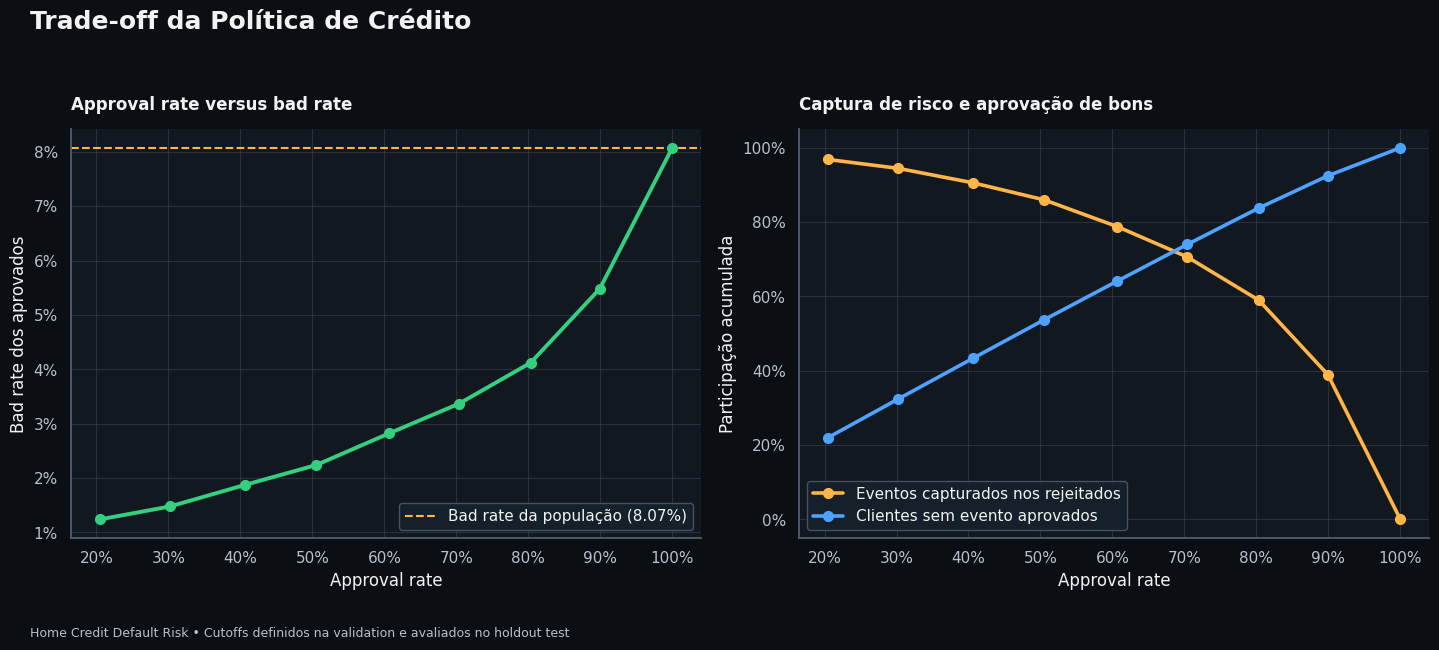

Figura salva em: /content/home-credit-default-risk/reports/figures/score_policy_tradeoff.png


In [30]:
# Visualização do trade-off entre aprovação e risco
background_color = "#0B0F14"
plot_background_color = "#111820"

blue_color = "#4DA3FF"
green_color = "#35D07F"
orange_color = "#FFB547"

primary_text_color = "#F2F2F2"
secondary_text_color = "#B8C0CC"
grid_color = "#35404D"

with plt.rc_context(
    {
        "font.family": "sans-serif",
        "text.color": primary_text_color,
        "axes.labelcolor": primary_text_color,
        "xtick.color": secondary_text_color,
        "ytick.color": secondary_text_color,
        "axes.titleweight": "bold",
    }
):
    figure, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(15, 6.5),
        facecolor=background_color,
    )

    for axis in axes:
        axis.set_facecolor(
            plot_background_color
        )

        axis.spines["top"].set_visible(
            False
        )

        axis.spines["right"].set_visible(
            False
        )

        axis.spines["left"].set_color(
            "#536171"
        )

        axis.spines["bottom"].set_color(
            "#536171"
        )

        axis.grid(
            color=grid_color,
            linewidth=0.8,
            alpha=0.65,
        )

        axis.xaxis.set_major_formatter(
            PercentFormatter(
                xmax=1,
                decimals=0,
            )
        )

        axis.yaxis.set_major_formatter(
            PercentFormatter(
                xmax=1,
                decimals=0,
            )
        )

    # Approval rate versus approved bad rate
    axes[0].plot(
        policy_plot_data[
            "approval_rate"
        ],
        policy_plot_data[
            "approved_bad_rate"
        ],
        color=green_color,
        marker="o",
        markersize=7,
        linewidth=2.8,
        zorder=3,
    )

    axes[0].axhline(
        portfolio_bad_rate,
        color=orange_color,
        linestyle="--",
        linewidth=1.5,
        label=(
            "Bad rate da população "
            f"({portfolio_bad_rate:.2%})"
        ),
    )

    axes[0].set_title(
        "Approval rate versus bad rate",
        loc="left",
        color=primary_text_color,
        pad=14,
    )

    axes[0].set_xlabel("Approval rate")
    axes[0].set_ylabel(
        "Bad rate dos aprovados"
    )

    # Captura de eventos e aprovação de bons
    axes[1].plot(
        policy_plot_data[
            "approval_rate"
        ],
        policy_plot_data[
            "rejected_event_capture"
        ],
        color=orange_color,
        marker="o",
        markersize=7,
        linewidth=2.6,
        label=(
            "Eventos capturados "
            "nos rejeitados"
        ),
        zorder=3,
    )

    axes[1].plot(
        policy_plot_data[
            "approval_rate"
        ],
        policy_plot_data[
            "approved_good_capture"
        ],
        color=blue_color,
        marker="o",
        markersize=7,
        linewidth=2.6,
        label=(
            "Clientes sem evento aprovados"
        ),
        zorder=3,
    )

    axes[1].set_title(
        "Captura de risco e aprovação de bons",
        loc="left",
        color=primary_text_color,
        pad=14,
    )

    axes[1].set_xlabel("Approval rate")
    axes[1].set_ylabel(
        "Participação acumulada"
    )

    for axis in axes:
        legend = axis.legend(
            frameon=True,
            facecolor="#17212B",
            edgecolor="#465466",
            framealpha=0.97,
        )

        for legend_text in (
            legend.get_texts()
        ):
            legend_text.set_color(
                primary_text_color
            )

    figure.suptitle(
        "Trade-off da Política de Crédito",
        fontsize=18,
        fontweight="bold",
        color=primary_text_color,
        x=0.055,
        ha="left",
    )

    figure.text(
        0.055,
        0.015,
        (
            "Home Credit Default Risk • "
            "Cutoffs definidos na validation "
            "e avaliados no holdout test"
        ),
        fontsize=9,
        color=secondary_text_color,
    )

    figure.tight_layout(
        rect=[0.03, 0.06, 1, 0.94]
    )

    POLICY_TRADEOFF_FIGURE_PATH = (
        paths.figures
        / "score_policy_tradeoff.png"
    )

    figure.savefig(
        POLICY_TRADEOFF_FIGURE_PATH,
        dpi=220,
        bbox_inches="tight",
        facecolor=background_color,
    )

    plt.show()

print(
    "Figura salva em: "
    f"{POLICY_TRADEOFF_FIGURE_PATH}"
)

## Governança da Política de Crédito

### 14. Impacto dos Cutoffs por Grupo

A análise de fairness de um modelo não se encerra nas métricas de discriminação e calibração. O impacto final depende da Política de Crédito aplicada sobre suas previsões.

Nesta etapa, serão calculados por grupo:

- approval rate;
- quantidade de clientes aprovados;
- bad rate dos aprovados;
- proporção dos eventos capturada entre os rejeitados.

Diferenças entre grupos não comprovam, isoladamente, discriminação indevida. Elas podem refletir diferenças na composição da população, nas taxas de eventos e nas demais características utilizadas pelo modelo.

Entretanto, como `CODE_GENDER` foi utilizado diretamente pelo statistical champion, qualquer diferença nas decisões exige análise adicional de governança. Em uma aplicação real, seria necessário comparar o resultado com uma versão do modelo sem o atributo sensível e investigar possíveis proxies.

In [31]:
# Localização da base com o atributo sensível
GENDER_COLUMN = "CODE_GENDER"

holdout_feature_candidates = [
    paths.data_processed
    / "modeling_holdout_test_full.parquet",
    paths.data_processed
    / "modeling_holdout_test.parquet",
]

holdout_features_path = next(
    (
        candidate_path
        for candidate_path
        in holdout_feature_candidates
        if candidate_path.exists()
    ),
    None,
)

if holdout_features_path is None:
    available_parquet_files = sorted(
        path.name
        for path in paths.data_processed.glob(
            "*.parquet"
        )
    )

    raise FileNotFoundError(
        "A base do holdout com CODE_GENDER "
        "não foi encontrada. "
        f"Arquivos disponíveis: "
        f"{available_parquet_files}"
    )

print(
    "Base selecionada: "
    f"{holdout_features_path}"
)

Base selecionada: /content/drive/MyDrive/home-credit-default-risk/data/processed/modeling_holdout_test_full.parquet


In [32]:
# Carregamento do atributo sensível
holdout_group_attributes = pd.read_parquet(
    holdout_features_path,
    columns=[
        ID_COLUMN,
        GENDER_COLUMN,
    ],
)

if holdout_group_attributes[
    ID_COLUMN
].duplicated().any():
    raise ValueError(
        "Existem identificadores duplicados "
        "na base de atributos."
    )

holdout_policy_group_data = (
    holdout_policy_data.merge(
        holdout_group_attributes,
        on=ID_COLUMN,
        how="left",
        validate="one_to_one",
    )
)

if holdout_policy_group_data[
    GENDER_COLUMN
].isna().any():
    raise ValueError(
        "Existem clientes sem CODE_GENDER."
    )

display(
    holdout_policy_group_data[
        GENDER_COLUMN
    ]
    .value_counts()
    .rename_axis(GENDER_COLUMN)
    .reset_index(name="clients")
)

,CODE_GENDER,clients
0,F,30429
1,M,15698


In [33]:
# Simulação da política por grupo
group_policy_records = []

for _, cutoff_row in policy_cutoffs.iterrows():
    score_cutoff = cutoff_row[
        "score_cutoff"
    ]

    for group_value, group_data in (
        holdout_policy_group_data.groupby(
            GENDER_COLUMN,
            observed=True,
        )
    ):
        approved_mask = (
            group_data["credit_score"]
            >= score_cutoff
        )

        rejected_mask = ~approved_mask

        group_clients = len(group_data)

        group_events = int(
            group_data[
                TARGET_COLUMN
            ].sum()
        )

        approved_clients = int(
            approved_mask.sum()
        )

        rejected_clients = int(
            rejected_mask.sum()
        )

        approved_events = int(
            group_data.loc[
                approved_mask,
                TARGET_COLUMN,
            ].sum()
        )

        rejected_events = int(
            group_data.loc[
                rejected_mask,
                TARGET_COLUMN,
            ].sum()
        )

        group_policy_records.append(
            {
                "target_approval_rate": (
                    cutoff_row[
                        "target_approval_rate"
                    ]
                ),
                "score_cutoff": score_cutoff,
                "group": group_value,
                "group_clients": group_clients,
                "group_event_rate": (
                    group_events
                    / group_clients
                ),
                "approved_clients": (
                    approved_clients
                ),
                "approval_rate": (
                    approved_clients
                    / group_clients
                ),
                "approved_bad_rate": (
                    approved_events
                    / approved_clients
                ),
                "rejected_clients": (
                    rejected_clients
                ),
                "rejected_bad_rate": (
                    rejected_events
                    / rejected_clients
                ),
                "rejected_event_capture": (
                    rejected_events
                    / group_events
                ),
            }
        )

group_policy_simulation = pd.DataFrame(
    group_policy_records
)

display(group_policy_simulation)

,target_approval_rate,score_cutoff,group,group_clients,group_event_rate,approved_clients,approval_rate,approved_bad_rate,rejected_clients,rejected_bad_rate,rejected_event_capture
0,0.2000,668.0324,F,30429,0.0696,7312,0.2403,0.0133,23117,0.0874,0.9542
1,0.2000,668.0324,M,15698,0.1023,2124,0.1353,0.0094,13574,0.1168,0.9875
2,0.3000,644.5170,F,30429,0.0696,10609,0.3486,0.0157,19820,0.0984,0.9212
3,0.3000,644.5170,M,15698,0.1023,3328,0.2120,0.0117,12370,0.1267,0.9757
4,0.4000,622.8721,F,30429,0.0696,13992,0.4598,0.0192,16437,0.1125,0.8730
5,0.4000,622.8721,M,15698,0.1023,4740,0.3019,0.0173,10958,0.1391,0.9489
6,0.5000,602.3671,F,30429,0.0696,17016,0.5592,0.0223,13413,0.1296,0.8206
7,0.5000,602.3671,M,15698,0.1023,6290,0.4007,0.0226,9408,0.1556,0.9116
8,0.6000,580.2656,F,30429,0.0696,20090,0.6602,0.0277,10339,0.1511,0.7375
9,0.6000,580.2656,M,15698,0.1023,7878,0.5018,0.0296,7820,0.1756,0.8549


In [34]:
# Construção das diferenças de approval rate entre grupos
group_approval_pivot = (
    group_policy_simulation
    .pivot(
        index=[
            "target_approval_rate",
            "score_cutoff",
        ],
        columns="group",
        values="approval_rate",
    )
    .reset_index()
)

if {
    "F",
    "M",
}.issubset(
    group_approval_pivot.columns
):
    group_approval_pivot[
        "approval_rate_gap_m_minus_f"
    ] = (
        group_approval_pivot["M"]
        - group_approval_pivot["F"]
    )

display(group_approval_pivot)

group,target_approval_rate,score_cutoff,F,M,approval_rate_gap_m_minus_f
0,0.2000,668.0324,0.2403,0.1353,-0.1050
1,0.3000,644.5170,0.3486,0.2120,-0.1366
2,0.4000,622.8721,0.4598,0.3019,-0.1579
3,0.5000,602.3671,0.5592,0.4007,-0.1585
4,0.6000,580.2656,0.6602,0.5018,-0.1584
5,0.7000,556.3876,0.7525,0.6097,-0.1428
6,0.8000,527.3916,0.8429,0.7265,-0.1164
7,0.9000,487.0499,0.9229,0.8536,-0.0693


### 15. Visualização do Approval Rate por Grupo

A visualização compara o approval rate geral com os approval rates observados em cada grupo para os mesmos cutoffs.

A distância vertical entre as curvas representa a diferença de aprovação produzida pela aplicação da mesma regra de score.

Os resultados possuem caráter descritivo e exploratório. As diferenças observadas não devem ser interpretadas isoladamente como evidência conclusiva de discriminação ou conformidade.

In [35]:
# Complementação das métricas de aprovação por grupo
if {
    "F",
    "M",
}.issubset(
    group_approval_pivot.columns
):
    group_approval_pivot[
        "approval_rate_gap_f_minus_m"
    ] = (
        group_approval_pivot["F"]
        - group_approval_pivot["M"]
    )

    group_approval_pivot[
        "approval_rate_ratio_m_over_f"
    ] = (
        group_approval_pivot["M"]
        / group_approval_pivot["F"]
    )

display(group_approval_pivot)

group,target_approval_rate,score_cutoff,F,M,approval_rate_gap_m_minus_f,approval_rate_gap_f_minus_m,approval_rate_ratio_m_over_f
0,0.2000,668.0324,0.2403,0.1353,-0.1050,0.1050,0.5631
1,0.3000,644.5170,0.3486,0.2120,-0.1366,0.1366,0.6081
2,0.4000,622.8721,0.4598,0.3019,-0.1579,0.1579,0.6567
3,0.5000,602.3671,0.5592,0.4007,-0.1585,0.1585,0.7165
4,0.6000,580.2656,0.6602,0.5018,-0.1584,0.1584,0.7601
5,0.7000,556.3876,0.7525,0.6097,-0.1428,0.1428,0.8103
6,0.8000,527.3916,0.8429,0.7265,-0.1164,0.1164,0.8619
7,0.9000,487.0499,0.9229,0.8536,-0.0693,0.0693,0.9249


In [36]:
# Preparação dos dados para visualização por grupo
overall_approval_by_cutoff = (
    policy_simulation[
        [
            "target_approval_rate",
            "approval_rate",
        ]
    ]
    .rename(
        columns={
            "approval_rate": (
                "overall_approval_rate"
            )
        }
    )
)

group_policy_plot_data = (
    group_approval_pivot.merge(
        overall_approval_by_cutoff,
        on="target_approval_rate",
        how="left",
        validate="one_to_one",
    )
)

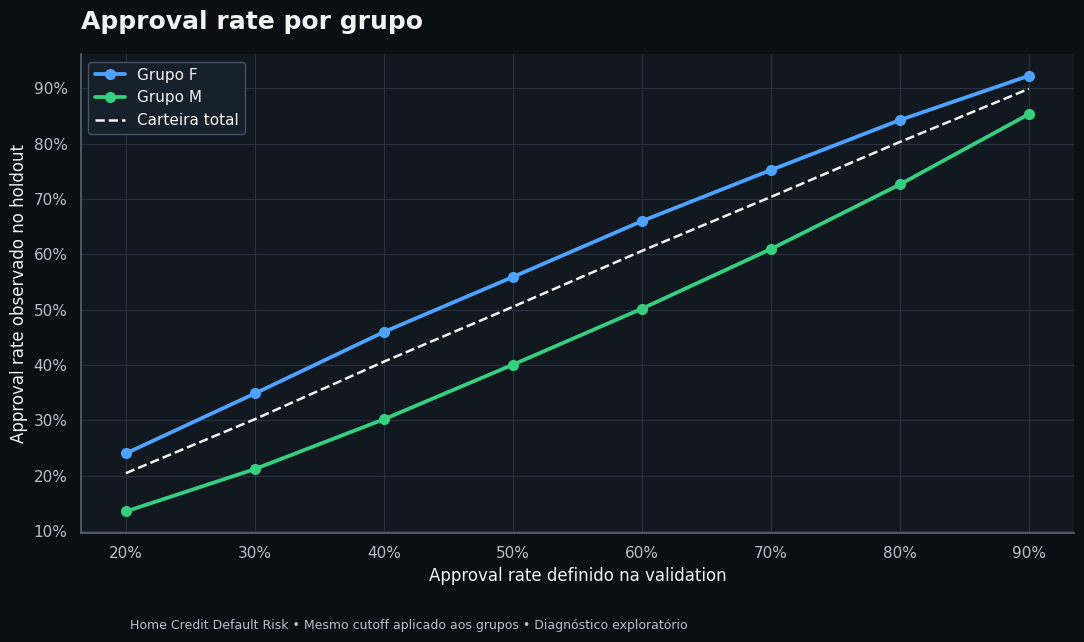

Figura salva em: /content/home-credit-default-risk/reports/figures/score_policy_group_approval_rate.png


In [37]:
# Visualização do approval rate por grupo
background_color = "#0B0F14"
plot_background_color = "#111820"

overall_color = "#F2F2F2"
group_f_color = "#4DA3FF"
group_m_color = "#35D07F"

primary_text_color = "#F2F2F2"
secondary_text_color = "#B8C0CC"
grid_color = "#35404D"

with plt.rc_context(
    {
        "font.family": "sans-serif",
        "text.color": primary_text_color,
        "axes.labelcolor": primary_text_color,
        "xtick.color": secondary_text_color,
        "ytick.color": secondary_text_color,
        "axes.titleweight": "bold",
    }
):
    figure, axis = plt.subplots(
        figsize=(11, 6.5),
        facecolor=background_color,
    )

    axis.set_facecolor(
        plot_background_color
    )

    axis.plot(
        group_policy_plot_data[
            "target_approval_rate"
        ],
        group_policy_plot_data["F"],
        color=group_f_color,
        marker="o",
        markersize=7,
        linewidth=2.7,
        label="Grupo F",
    )

    axis.plot(
        group_policy_plot_data[
            "target_approval_rate"
        ],
        group_policy_plot_data["M"],
        color=group_m_color,
        marker="o",
        markersize=7,
        linewidth=2.7,
        label="Grupo M",
    )

    axis.plot(
        group_policy_plot_data[
            "target_approval_rate"
        ],
        group_policy_plot_data[
            "overall_approval_rate"
        ],
        color=overall_color,
        linestyle="--",
        linewidth=1.8,
        label="Carteira total",
    )

    axis.set_title(
        "Approval rate por grupo",
        loc="left",
        fontsize=18,
        color=primary_text_color,
        pad=18,
    )

    axis.set_xlabel(
        "Approval rate definido na validation"
    )

    axis.set_ylabel(
        "Approval rate observado no holdout"
    )

    axis.xaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=0,
        )
    )

    axis.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=1,
            decimals=0,
        )
    )

    axis.grid(
        color=grid_color,
        linewidth=0.8,
        alpha=0.65,
    )

    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

    axis.spines["left"].set_color(
        "#536171"
    )

    axis.spines["bottom"].set_color(
        "#536171"
    )

    legend = axis.legend(
        frameon=True,
        facecolor="#17212B",
        edgecolor="#465466",
        framealpha=0.97,
    )

    for legend_text in legend.get_texts():
        legend_text.set_color(
            primary_text_color
        )

    figure.text(
        0.125,
        0.02,
        (
            "Home Credit Default Risk • "
            "Mesmo cutoff aplicado aos grupos "
            "• Diagnóstico exploratório"
        ),
        fontsize=9,
        color=secondary_text_color,
    )

    figure.tight_layout(
        rect=[0, 0.06, 1, 1]
    )

    GROUP_APPROVAL_FIGURE_PATH = (
        paths.figures
        / "score_policy_group_approval_rate.png"
    )

    figure.savefig(
        GROUP_APPROVAL_FIGURE_PATH,
        dpi=220,
        bbox_inches="tight",
        facecolor=background_color,
    )

    plt.show()

print(
    "Figura salva em: "
    f"{GROUP_APPROVAL_FIGURE_PATH}"
)

## Persistência dos Resultados

### 16. Persistência dos Artefatos

Os principais resultados do notebook serão persistidos para permitir reprodução, auditoria e utilização posterior.

Serão armazenados:

- parâmetros da escala de score;
- thresholds dos ratings;
- scores e ratings por cliente;
- perfil das faixas de risco;
- cenários de Política de Crédito;
- diagnóstico da política por grupo;
- tabelas utilizadas nas análises.

Os arquivos de dados e metadados pesados serão armazenados no cache do Google Drive. As tabelas e figuras destinadas ao relatório permanecerão na estrutura versionada do projeto.

In [38]:
# Construção da configuração de score e ratings
score_policy_config = {
    "champion_model": "LightGBM Challenger",
    "champion_pd_column": (
        CHAMPION_PD_COLUMN
    ),
    "target_column": TARGET_COLUMN,
    "id_column": ID_COLUMN,
    "score_parameters": {
        "base_score": BASE_SCORE,
        "base_odds": BASE_ODDS,
        "pdo": PDO,
        "factor": float(
            SCORE_FACTOR
        ),
        "offset": float(
            SCORE_OFFSET
        ),
    },
    "rating_definition_sample": (
        "validation"
    ),
    "rating_thresholds": {
        "score_q20": float(
            SCORE_Q20
        ),
        "score_q40": float(
            SCORE_Q40
        ),
        "score_q60": float(
            SCORE_Q60
        ),
        "score_q80": float(
            SCORE_Q80
        ),
    },
    "rating_order": [
        "A",
        "B",
        "C",
        "D",
        "E",
    ],
    "decision_rule": (
        "Approve when credit_score "
        "is greater than or equal "
        "to the selected cutoff."
    ),
    "governance_warning": (
        "The champion model directly uses "
        "CODE_GENDER. Results are exploratory "
        "and are not a production policy."
    ),
}

In [39]:
# Definição dos caminhos dos artefatos
SCORE_POLICY_CONFIG_PATH = (
    paths.metadata
    / "score_policy_config.json"
)

SCORE_RESULTS_PATH = (
    paths.data_processed
    / "champion_score_and_rating.parquet"
)

SCORE_SUMMARY_PATH = (
    paths.tables
    / "score_sample_summary.csv"
)

SCORE_RELATIONSHIP_PATH = (
    paths.tables
    / "score_relationship_summary.csv"
)

RATING_THRESHOLDS_PATH = (
    paths.tables
    / "score_rating_thresholds.csv"
)

RATING_PROFILE_PATH = (
    paths.tables
    / "score_rating_profile.csv"
)

POLICY_CUTOFFS_PATH = (
    paths.tables
    / "credit_policy_cutoffs.csv"
)

POLICY_SIMULATION_PATH = (
    paths.tables
    / "credit_policy_simulation.csv"
)

GROUP_POLICY_SIMULATION_PATH = (
    paths.tables
    / "credit_policy_group_simulation.csv"
)

GROUP_APPROVAL_GAP_PATH = (
    paths.tables
    / "credit_policy_group_approval_gap.csv"
)

In [40]:
# Persistência da configuração
with open(
    SCORE_POLICY_CONFIG_PATH,
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        score_policy_config,
        file,
        ensure_ascii=False,
        indent=2,
    )

In [41]:
# Persistência dos scores e ratings por cliente
score_results = score_data[
    [
        ID_COLUMN,
        TARGET_COLUMN,
        "sample",
        CHAMPION_PD_COLUMN,
        "credit_score",
        "credit_score_rounded",
        "risk_rating",
    ]
].copy()

score_results.to_parquet(
    SCORE_RESULTS_PATH,
    index=False,
)

In [42]:
# Persistência das tabelas analíticas
score_sample_summary.to_csv(
    SCORE_SUMMARY_PATH,
    index=False,
)

score_relationship_summary.to_csv(
    SCORE_RELATIONSHIP_PATH,
    index=False,
)

rating_thresholds.to_csv(
    RATING_THRESHOLDS_PATH,
    index=False,
)

rating_profile_comparison.to_csv(
    RATING_PROFILE_PATH,
    index=False,
)

policy_cutoffs.to_csv(
    POLICY_CUTOFFS_PATH,
    index=False,
)

policy_simulation.to_csv(
    POLICY_SIMULATION_PATH,
    index=False,
)

group_policy_simulation.to_csv(
    GROUP_POLICY_SIMULATION_PATH,
    index=False,
)

group_approval_pivot.to_csv(
    GROUP_APPROVAL_GAP_PATH,
    index=False,
)

print(
    "Artefatos persistidos com sucesso."
)

Artefatos persistidos com sucesso.


In [43]:
# Construção do inventário dos artefatos
persisted_artifacts = [
    SCORE_POLICY_CONFIG_PATH,
    SCORE_RESULTS_PATH,
    SCORE_SUMMARY_PATH,
    SCORE_RELATIONSHIP_PATH,
    RATING_THRESHOLDS_PATH,
    RATING_PROFILE_PATH,
    POLICY_CUTOFFS_PATH,
    POLICY_SIMULATION_PATH,
    GROUP_POLICY_SIMULATION_PATH,
    GROUP_APPROVAL_GAP_PATH,
    RATING_PROFILE_FIGURE_PATH,
    POLICY_TRADEOFF_FIGURE_PATH,
    GROUP_APPROVAL_FIGURE_PATH,
]

artifact_inventory_records = []

for artifact_path in persisted_artifacts:
    artifact_inventory_records.append(
        {
            "artifact": (
                artifact_path.name
            ),
            "path": str(
                artifact_path
            ),
            "exists": (
                artifact_path.exists()
            ),
            "size_kb": (
                artifact_path.stat().st_size
                / 1024
                if artifact_path.exists()
                else np.nan
            ),
        }
    )

artifact_inventory = pd.DataFrame(
    artifact_inventory_records
)

display(artifact_inventory)

,artifact,path,exists,size_kb
0,score_policy_config.json,/content/drive/MyDrive/home-credit-default-ris...,True,0.7910
1,champion_score_and_rating.parquet,/content/drive/MyDrive/home-credit-default-ris...,True,"7,588.0693"
2,score_sample_summary.csv,/content/home-credit-default-risk/reports/tabl...,True,0.4668
3,score_relationship_summary.csv,/content/home-credit-default-risk/reports/tabl...,True,0.2197
4,score_rating_thresholds.csv,/content/home-credit-default-risk/reports/tabl...,True,0.2734
5,score_rating_profile.csv,/content/home-credit-default-risk/reports/tabl...,True,2.3311
6,credit_policy_cutoffs.csv,/content/home-credit-default-risk/reports/tabl...,True,0.4834
7,credit_policy_simulation.csv,/content/home-credit-default-risk/reports/tabl...,True,1.9043
8,credit_policy_group_simulation.csv,/content/home-credit-default-risk/reports/tabl...,True,2.5498
9,credit_policy_group_approval_gap.csv,/content/home-credit-default-risk/reports/tabl...,True,1.1592


## Conclusão

### 17. Principais Resultados

Este notebook transformou as PDs produzidas pelo LightGBM em uma escala de score e demonstrou como essa medida pode apoiar a construção de uma Política de Crédito.

A escala foi parametrizada com:

- Base Score de 600 pontos;
- Base Odds de 20 bons para 1 mau;
- PDO de 50 pontos.

A transformação preservou integralmente a ordenação do modelo, apresentando correlação de Spearman igual a `-1` entre PD e score. Portanto, clientes com maior risco receberam scores menores, sem alteração da capacidade discriminatória do statistical champion.

Os thresholds definidos na validation produziram cinco ratings ordenados no holdout test:

| Rating | Interpretação | Bad rate observado |
|:------:|:--------------|--------------------:|
| A | Menor risco | 1,24% |
| B | Risco baixo | 2,52% |
| C | Risco intermediário | 4,74% |
| D | Risco elevado | 8,12% |
| E | Maior risco | 24,21% |

O rating E representou aproximadamente 19,67% da carteira e concentrou 59,00% dos eventos. Em contraste, o rating A representou 20,46% da carteira e concentrou apenas 3,14% dos eventos.

Esses resultados mostram que o score consegue produzir faixas de risco ordenadas, discriminantes e razoavelmente calibradas.

### 18. Simulação da Política de Crédito

A simulação demonstrou que não existe um cutoff universalmente ótimo. A escolha depende do equilíbrio entre aprovação, risco, retorno e apetite institucional.

Em um cenário ilustrativo com cutoff próximo de 527 pontos:

- o approval rate foi de 80,33%;
- o approved bad rate foi de 4,12%;
- os 19,67% de clientes rejeitados concentraram 59,00% dos eventos;
- 83,78% dos clientes sem evento foram aprovados.

Uma política mais restritiva reduziu o bad rate dos aprovados, mas também rejeitou uma parcela maior de clientes sem evento. Uma política mais permissiva aumentou a aprovação, mas elevou o risco observado da carteira aprovada.

A escolha do cutoff não foi tratada como um problema de maximização de accuracy ou F1. Em crédito, essa decisão deve considerar perda esperada, receita, custo de oportunidade, capital, capacidade operacional e estratégia comercial.

### 19. Governança e Fairness

A aplicação dos mesmos cutoffs produziu approval rates diferentes entre os grupos de `CODE_GENDER`.

Nos cenários intermediários, a diferença entre os grupos chegou a aproximadamente 16 pontos percentuais. No cenário de aproximadamente 80% de aprovação geral, os approval rates foram:

- grupo `F`: 84,29%;
- grupo `M`: 72,65%.

Os grupos também apresentaram taxas de eventos diferentes na população. Portanto, os resultados não comprovam causalmente discriminação e não podem ser atribuídos exclusivamente ao uso direto de `CODE_GENDER`.

Entretanto, como o statistical champion utiliza diretamente esse atributo e ele apresentou relevância na análise por SHAP, os resultados constituem um alerta material de governança.

Antes de qualquer aplicação real, seria necessário:

- desenvolver uma versão do modelo sem `CODE_GENDER`;
- investigar possíveis proxies;
- comparar performance e impacto entre as versões;
- definir critérios institucionais de fairness;
- submeter o modelo e a política às revisões de Risco, Compliance e Jurídico;
- monitorar os impactos após a implantação.

### 20. Limitações

A simulação possui limitações importantes:

- os dados não incluem estimativas validadas de LGD e EAD;
- não foram considerados receita, margem, custo de capital ou recuperação;
- o cutoff não foi otimizado por rentabilidade ou Expected Loss;
- o target representa a definição de dificuldade de pagamento da competição;
- os resultados dos rejeitados são conhecidos na base, situação diferente de uma operação real;
- não foi aplicado um método de reject inference;
- as faixas de risco são relativas à população analisada;
- o modelo não foi aprovado para utilização em produção.

Consequentemente, os cenários apresentados possuem finalidade educacional e demonstrativa.

### 21. Encerramento

O projeto evidencia a separação entre modelagem de risco e decisão de crédito:

> O modelo estima e ordena o risco. A Política de Crédito transforma essa informação em decisões, considerando objetivos de negócio, restrições, governança e apetite de risco.

O LightGBM foi selecionado como statistical champion devido à sua superioridade nas métricas do holdout e no paired bootstrap. A Logistic Regression foi mantida como interpretable benchmark.

A transformação de PD em score, a criação dos ratings e a simulação dos cutoffs completam a conexão entre o desenvolvimento do modelo e sua possível utilização pela área de Política de Crédito, sem confundir previsão estatística com decisão automática de concessão.